# Effects of Rainfall Events on Erosion and Deposition
# Motivation

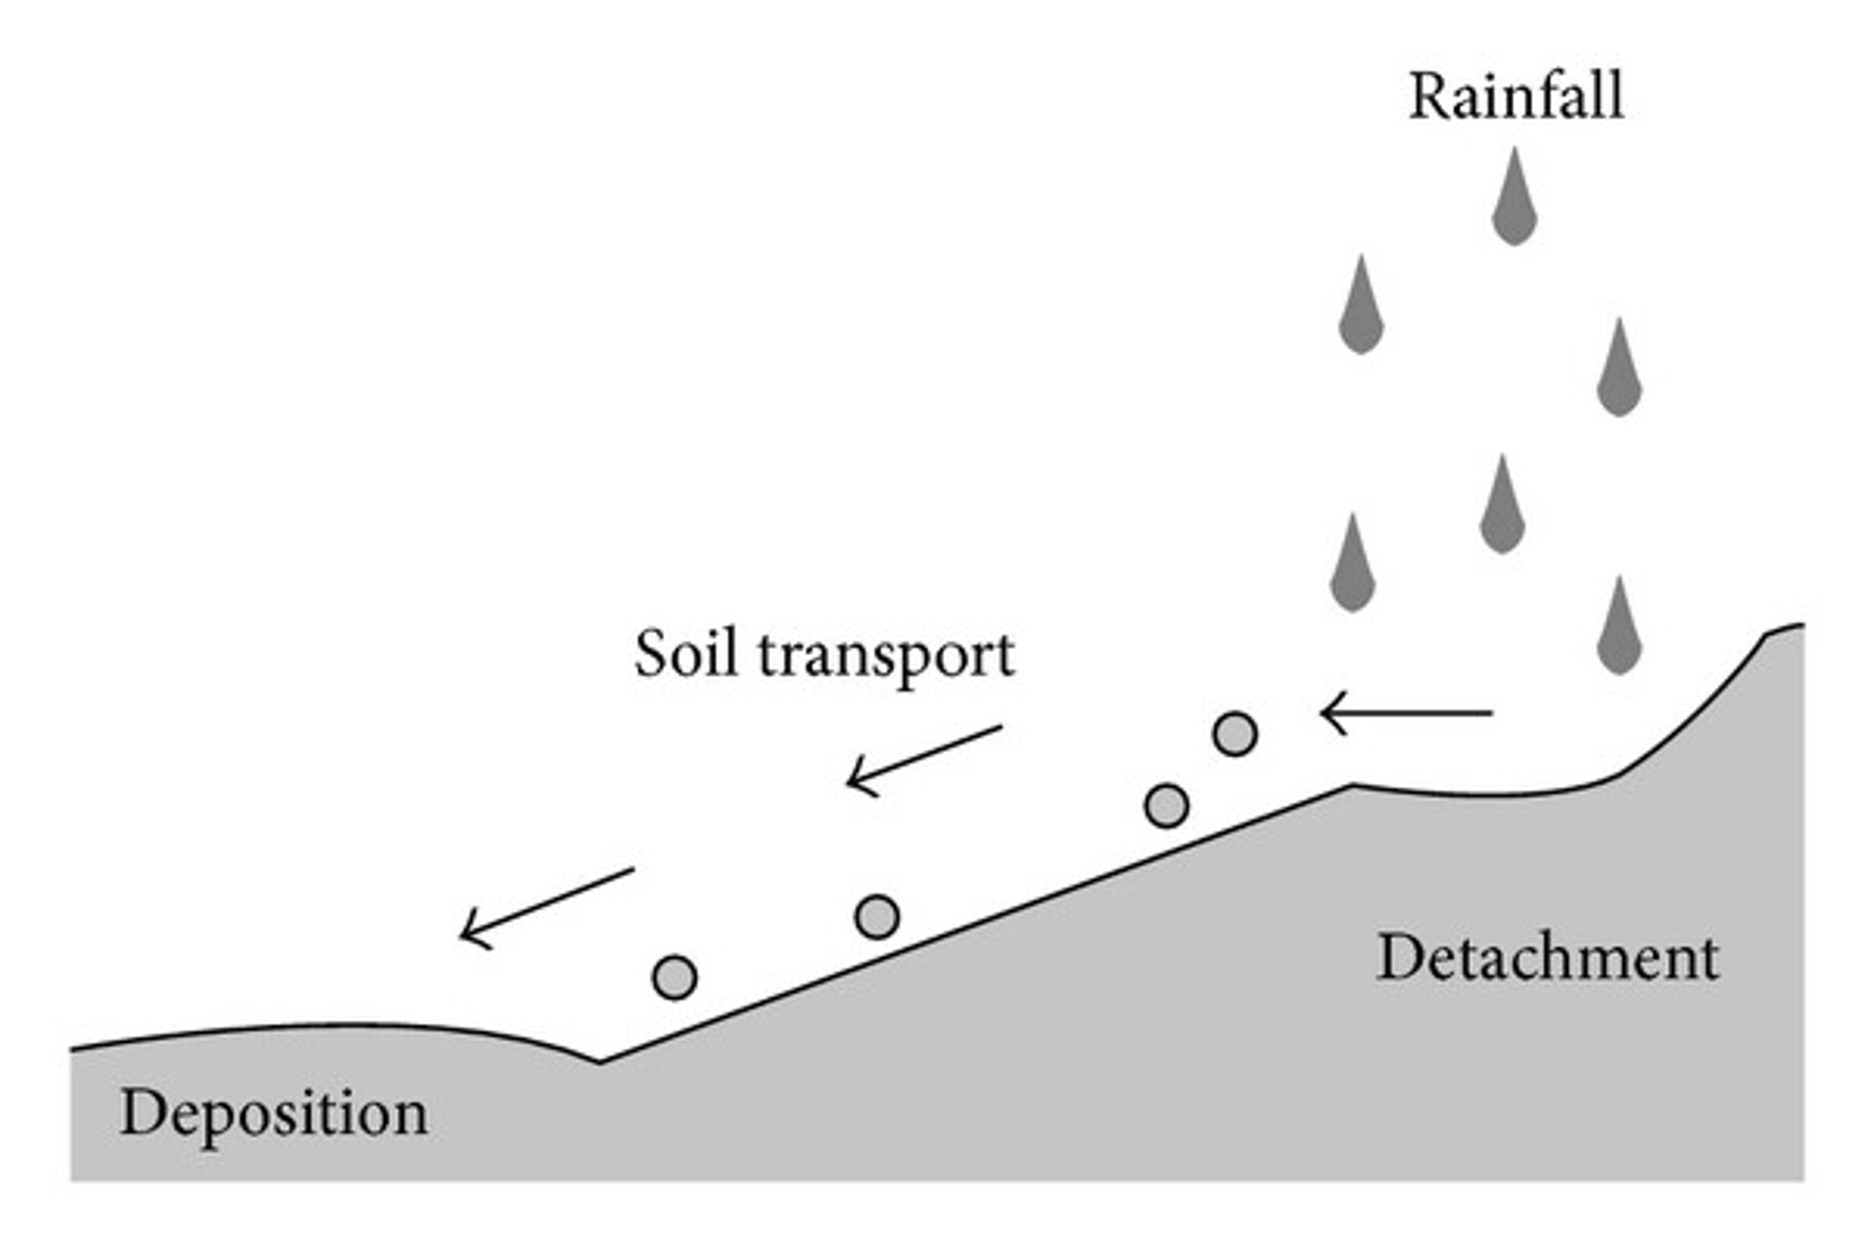

*Figure 1. Schematic showing rainfall-driven soil detachment, sediment transport, and deposition. Reproduced from Matsumoto et al. (2016).*

## Overview

Rainfall generates runoff that can detach, transport, and deposit sediment. Higher rainfall intensity can produce greater runoff and discharge, which may increase erosion and sediment transport.

In this notebook, we use Landlab to compare:

- constant default runoff
- variable runoff representing rainfall events

We examine how these runoff conditions affect erosion, deposition, sediment transport, and changes in bed elevation.

## Conceptual Model

The model follows the sequence below:

```text
Rainfall event
      ↓
Runoff
      ↓
Discharge and flow routing
      ↓
Sediment entrainment and transport
      ↓
Erosion or deposition
      ↓
Bed-elevation change
      ↓
Updated flow routing
```

## Import Libraries and Landlab Components
Python libraries and Landlab components are imported that are required to build the model, run the simulations, visualize the results, and create the comparison animation.

In [4]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import trange
from PIL import Image, ImageDraw

from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
    LinearDiffuser,
    ChannelProfiler,
)
from landlab.plot.graph import plot_graph

## Create the Model Grid
Raster grid with 150 rows, 200 columns, and 10 m spacing between nodes. Small random elevation values are added to create an initially uneven surface.

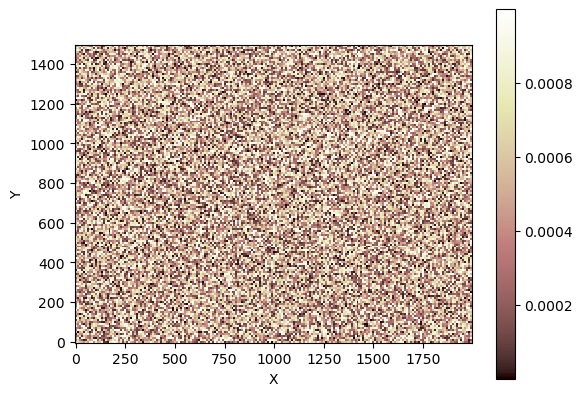

In [32]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

## Flow-Routing and Incision Parameters

FlowAccumulator routes water across the grid using the D8 method. FastscapeEroder  uses drainage area and slope to erode the landscape and develop a drainage network.

In [33]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

## Model Time and Uplift

Model ran for 3 million years using a 1,000-year timestep to create topography. A constant uplift rate is applied to the interior grid nodes.

In [34]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.00001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

## Boundary Conditions

All grid edges closed and one fixed-elevation outlet at node 0 created. Water and sediment leave the model through this outlet.

In [35]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

## Fluvial model to develop the Initial Drainage Network

At each timestep, the model applies uplift, routes flow, and calculates fluvial incision. This processes creates the drainage network used in the sediment-transport simulations.

In [36]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 1.0006938879715463
model run time 200000
maximum elevation 2.0004510054363505
model run time 300000
maximum elevation 3.0002782913350146
model run time 400000
maximum elevation 4.000194915640722
model run time 500000
maximum elevation 5.000131802837059
model run time 600000
maximum elevation 6.000089715510533
model run time 700000
maximum elevation 7.000064207010703
model run time 800000
maximum elevation 8.000052217817704
model run time 900000
maximum elevation 9.00003751271444
model run time 1000000
maximum elevation 10.000024682098678
model run time 1100000
maximum elevation 11.000017462476396
model run time 1200000
maximum elevation 12.000012451046452
model run time 1300000
maximum elevation 13.000008738273275
model run time 1400000
maximum elevation 14.00000686602208
model run time 1500000
maximum elevation 15.000005158951907
model run time 1600000
maximum elevation 16.00000254465875
model run time 1700000
maximum elevation 16.99976304203223

## Initial Topography

Initial topography created.

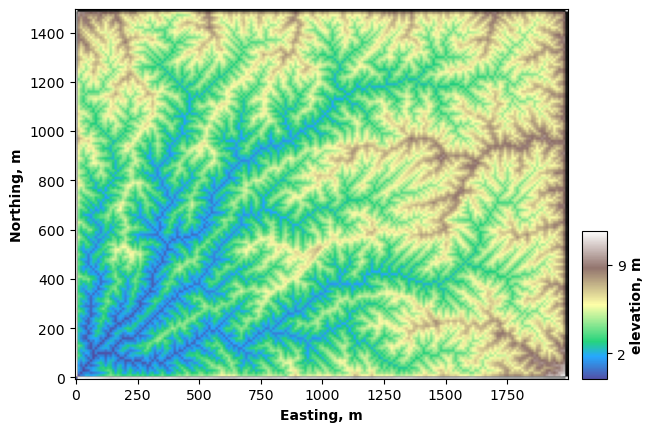

In [38]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

## A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

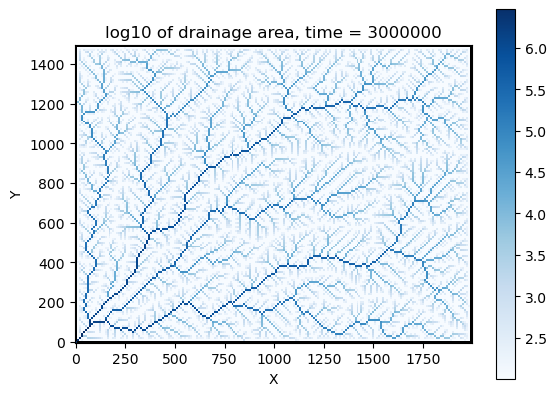

In [39]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

### Initiate Channel Profiler

Find out how many nodes our channel has, so we can save information later about them in the for loop.Make empty arrays of size where the number of rows is the number of timesteps, and the number of columns is the number of nodes in our main channel.

In [40]:
profiler = ChannelProfiler(
    mg,)
profiler.run_one_step()

# lp = list(profiler.data_structure[0].values())[0]["ids"]
# lpn = np.zeros([30, 234])
# lpd = np.zeros([30, 234])
# lpe = np.zeros([30, 234])
lpn = []
lpd = []
lpe = []

## SPACE with Constant Default Runoff
SPACE represents sediment entrainment, sediment transport, deposition, and bedrock erosion across a Landlab grid.

In this first scenario, FlowAccumulator uses constant default runoff. 

## Assign Soil Depth




In [41]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 10.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

## Space Parameters
We tried to select these parameters from the same literature that the model was developed. (Shobe et al., 2017) 

In [24]:
ha = Space(
    mg,              # Landlab ModelGrid
    K_sed=0.01,      # sediment erodibility
    K_br=0.001,      # bedrock erodibility
    F_f=1,           # fraction of permanently suspendable fines
    phi=0.1,         # sediment porosity [-]
    H_star=1.0,      # thickness required for full entrainment [L]
    v_s=1,           # effective settling velocity [L/T]
    m_sp=0.5,         # drainage-area/discharge exponent
    n_sp=1.0,       # channel-slope exponent
    sp_crit_sed=0,    # critical stream power for sediment erosion
    sp_crit_br=0,    # critical stream power for bedrock erosion
)

## Field Calculated for different parameters
Creates empty lists to store topographic elevation, sediment flux, discharge, bedrock elevation, and longitudinal channel profiles during the simulation.

Grid topo stores a copy of the complete elevation grid at every timestep. The other variables in this section record values at outlet node 0.

In [22]:
Grid_topo = []
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

### SPACE Component Run with Constant Default Runoff

The SPACE model is run for 30 timesteps using a constant default runoff of 1.0 model length unit per time unit.

At each timestep, the model:

1. Routes flow across the current topography.
2.  Identifies and routes water through depressions.
3. Calculates sediment entrainment, transport, deposition, and bedrock erosion.
4. Extracts the main-channel longitudinal profile.
5. Stores model fields and saves a figure.

In [28]:
os.makedirs("Results/SpaceWithoutRunoff", exist_ok=True)

### This one takes 10 mins to run
space_dt = 10.0
df = DepressionFinderAndRouter(mg)
for _ in trange(30):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8")
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)

    profiler.run_one_step()
    ids = list(profiler.data_structure[0].values())[0]["ids"]
    distances = list(profiler.data_structure[0].values())[0]["distances"]
    # lpn[_, :] = list(profiler.data_structure[0].values())[0]["ids"]
    # lpd[_, :] = list(profiler.data_structure[0].values())[0]["distances"]
    # lpe[_, :] = mg.at_node["topographic__elevation"][lpn[_].astype(int)]
    lpn.append(ids)
    lpd.append(distances)
    lpe.append(mg.at_node["topographic__elevation"][ids.astype(int)])
    
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    elevation_grid = mg.at_node["topographic__elevation"].copy()
    Grid_topo.append(elevation_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.sca(axes[0])
    imshow_grid(mg, elevation_grid, cmap="Spectral", vmin=0, vmax=20)
    axes[0].set_title(f"Topographic Elevation at {_} years")
    plt.sca(axes[1])
    elev_diff = Grid_topo[0] - elevation_grid
    imshow_grid(mg, elev_diff, cmap="Spectral", vmin=0, vmax=10)

    axes[1].set_title(f"Accumulated Erosion at {_} year")
    plt.tight_layout()
    plt.savefig(f"Results/SpaceWithoutRunoff/SpaceWithoutRunoff_Year_{_:02d}.png", dpi=300)
    plt.close(fig)

100%|██████████| 30/30 [01:30<00:00,  3.02s/it]


#### Visualizing the Output

### Visualize Topographic Change

We Compare the initial topography, final topography, and accumulated erosion produced by the constant-runoff simulation.

Accumulated erosion is calculated as:

$$E = z_{\mathrm{initial}} - z_{\mathrm{final}}$$

Positive values indicate elevation loss (erosion), while negative values indicate elevation gain (deposition).

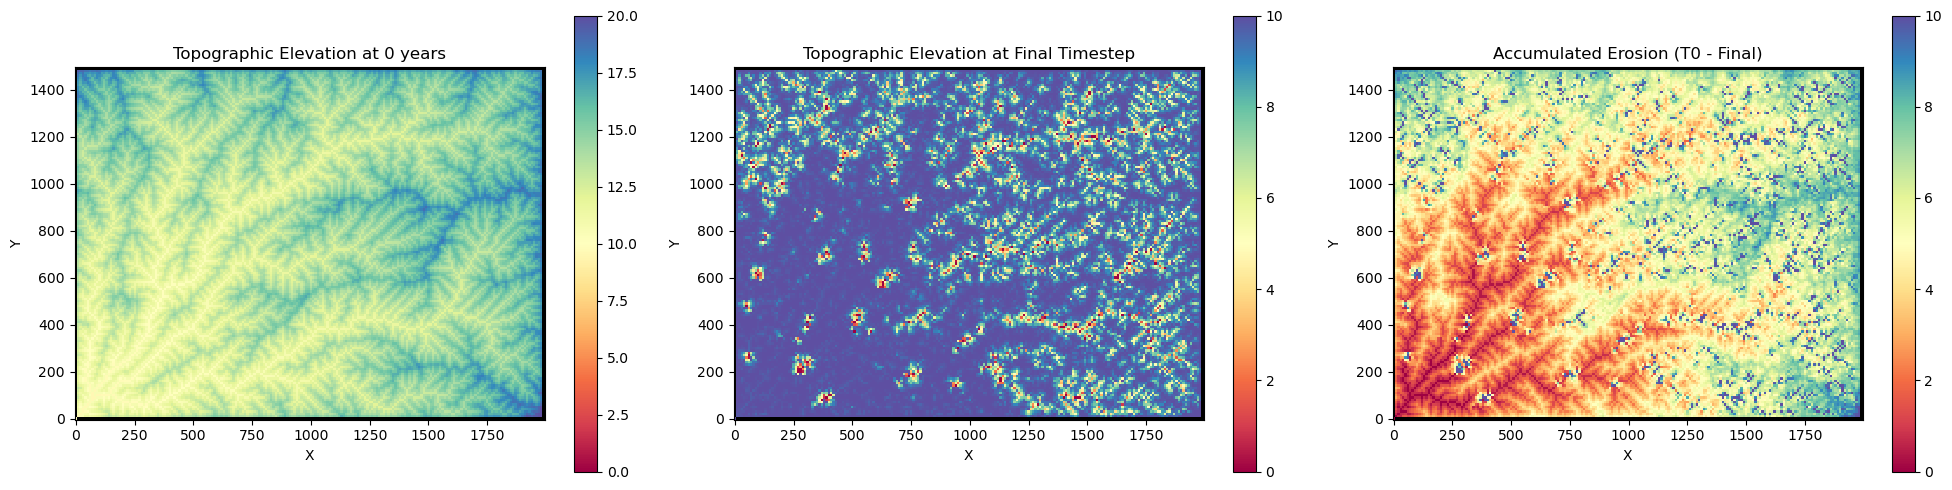

In [68]:
topoelvtn_diff = Grid_topo[0] - Grid_topo[-1]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.sca(axes[0])
imshow_grid(mg, Grid_topo[0], cmap="Spectral", vmin=0, vmax=20)
axes[0].set_title("Topographic Elevation at 0 years")
plt.sca(axes[1])
imshow_grid(mg, Grid_topo[-1], cmap="Spectral", vmin=0, vmax=10)
axes[1].set_title("Topographic Elevation at Final Timestep")
plt.sca(axes[2])
imshow_grid(mg, topoelvtn_diff, cmap="Spectral", vmin=0, vmax=10)
axes[2].set_title("Accumulated Erosion (T0 - Final)")
plt.tight_layout()
plt.show()

## Resuly Analysis


1. First Figure is Initial Topography
   
2. Second figure is the final Topography after running SPACE component

3. Third figures shows the correct physical idea that the greatest elevation changes occur along the drainage network whi3. The third figure shows the correct physical idea that the greatest elevation changes occur along the drainage network, which shows stronger erosion within the channels.ch shows stronger erosion within the channels.

### Higher Erosion

F_f=1  due to this condition all eroded bedrock becomes permanently suspended fines. Therefore, bedrock erosion supplies no coarse sediment for local deposition. We can try F_f=0.2 so that tells # 80% can enter the coarse sediment load

Grid mainly contains connected channels leading to an open outlet. Sediment can leave the model instead of accumulating downstream.

Negative values are clipped with vmin=0 (thats why we cannnot see deposition) 
 

## Profile Comparision 

The red line represents the first saved profile, and the blue line represents the final profile after the SPACE simulation.

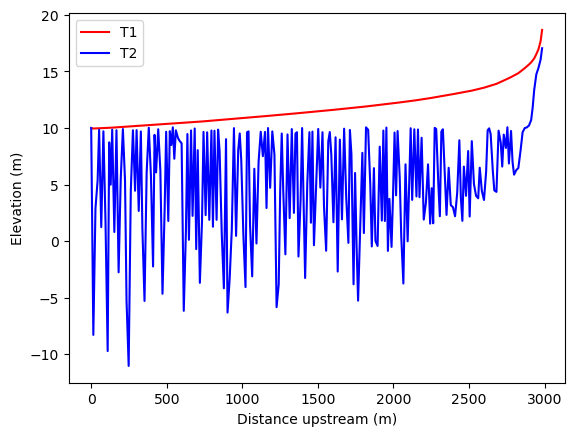

In [31]:
plt.plot(lpd[0], lpe[0], label="T1", color="red")   #one main channel from the largest-drainage-area outlet toward its headwater
plt.plot(lpd[0],Grid_topo[-1][np.asarray(lpn[0], dtype=int)],label="T2",color="blue",)  #lpn[0] contains the nodes of the first selected main channel.
plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

### Results Interpretation


The final profile is generally lower than the first saved profile, indicating substantial channel incision. 

The sharp and irregular drops may indicate numerical instability caused by the timestep or erosion parameters.

## SPACE with Variable Runoff
SPACE represents sediment entrainment, sediment transport, deposition, and bedrock erosion across a Landlab grid.

In this Asecondecond scenario, FlowAccumulator uses variable runoff(event based)

## Instantiate a grid

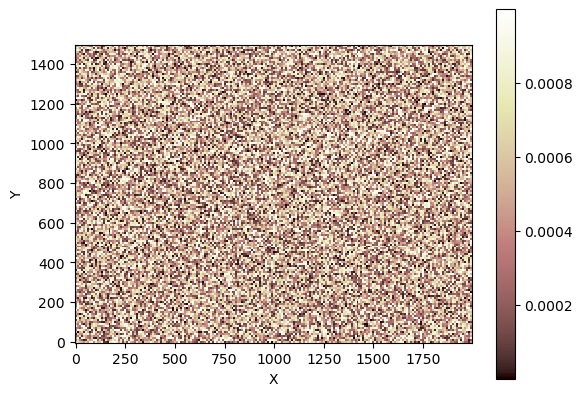

In [44]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

#### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [45]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

#### Set model time and uplift parameters

In [46]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.00001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [47]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

#### Run the fluvial model

In [48]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 1.0006938879715463
model run time 200000
maximum elevation 2.0004510054363505
model run time 300000
maximum elevation 3.0002782913350146
model run time 400000
maximum elevation 4.000194915640722
model run time 500000
maximum elevation 5.000131802837059
model run time 600000
maximum elevation 6.000089715510533
model run time 700000
maximum elevation 7.000064207010703
model run time 800000
maximum elevation 8.000052217817704
model run time 900000
maximum elevation 9.00003751271444
model run time 1000000
maximum elevation 10.000024682098678
model run time 1100000
maximum elevation 11.000017462476396
model run time 1200000
maximum elevation 12.000012451046452
model run time 1300000
maximum elevation 13.000008738273275
model run time 1400000
maximum elevation 14.00000686602208
model run time 1500000
maximum elevation 15.000005158951907
model run time 1600000
maximum elevation 16.00000254465875
model run time 1700000
maximum elevation 16.99976304203223

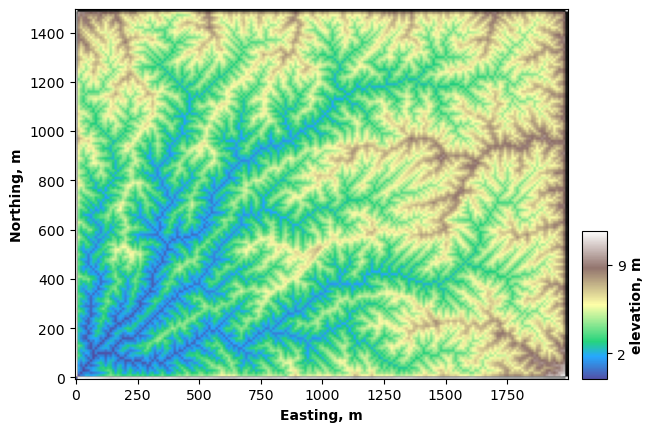

In [49]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

#### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

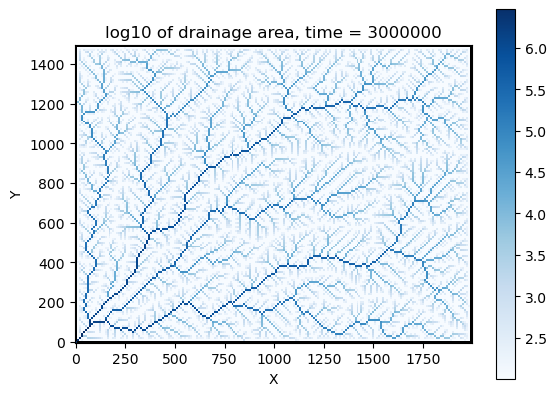

In [50]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Initiate Channel Profiler
Find out how many nodes our channel has, so we can save information later about them in the for loop.Make empty arrays of size where the number of rows is the number of timesteps, and the number of columns is the number of nodes in our main channel.

In [51]:
profiler = ChannelProfiler(
    mg,)
profiler.run_one_step()

# lp = list(profiler.data_structure[0].values())[0]["ids"]
# lpn = np.zeros([30, 234])
# lpd = np.zeros([30, 234])
# lpe = np.zeros([30, 234])
lpn = []
lpd = []
lpe = []

###  Variable Runoff Creation

Variable Runoff is taken as m/yr.Therefore the timeseries of runoff is taken as higher value and shows the event based type of series. Further the real sceanrios can also be used in this model

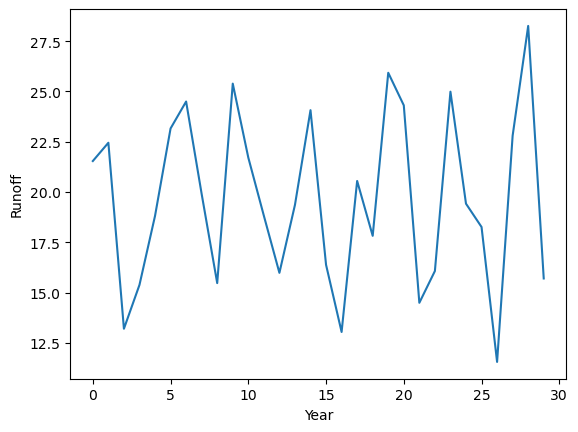

In [52]:
runoff_array = np.array([21.54, 22.45, 13.2, 15.38, 18.81, 23.16, 24.5, 19.9, 15.47, 25.39,
                          21.71, 18.82, 15.98, 19.36, 24.07, 16.38, 13.04, 20.55, 17.82, 25.93,
                          24.31, 14.49, 16.07, 24.99, 19.42, 18.26, 11.55, 22.8, 28.26, 15.7])

# np.random.seed(33)
# runoff_array = np.random.uniform(15, 30, 30)

plt.plot(runoff_array)
plt.xlabel("Year")
plt.ylabel("Runoff")
plt.show()

### Soil Depth Assign

In [53]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 10.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

## SPACE with Variable Runoff
SPACE represents sediment entrainment, sediment transport, deposition, and bedrock erosion across a Landlab grid.

In this first scenario, FlowAccumulator uses variable runoff. 

In [54]:
ha = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=1,
    phi=0.1,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

## Field Calculated for different parameters
Creates empty lists to store topographic elevation, sediment flux, discharge, bedrock elevation, and longitudinal channel profiles during the simulation.

Grid topo stores a copy of the complete elevation grid at every timestep. The other variables in this section record values at outlet node 0.

In [55]:
Grid_topo = []
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

# mg.at_node["topographic__elevation"][0],
# mg.at_node["sediment__influx"][0],
# mg.at_node["sediment__outflux"][0], 
# mg.at_node["bedrock__elevation"][0],
# mg.at_node["surface_water__discharge"][0]

### SPACE Component Run with Constant Default Runoff

The SPACE model is run for 30 timesteps using a varaible runoff of 1.0 model length unit per time unit.

At each timestep, the model:

1. Routes flow across the current topography.
2.  Identifies and routes water through depressions.
3. Calculates sediment entrainment, transport, deposition, and bedrock erosion.
4. Extracts the main-channel longitudinal profile.
5. Stores model fields and saves a figure.

In [56]:
### This one takes 15 mins to run

os.makedirs("Results/SpaceWithRunoff", exist_ok=True)

space_dt = 10.0
df = DepressionFinderAndRouter(mg) 
for _ in trange(30):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)

    profiler.run_one_step()
    ids = list(profiler.data_structure[0].values())[0]["ids"]
    distances = list(profiler.data_structure[0].values())[0]["distances"]
    # lpn[_, :] = list(profiler.data_structure[0].values())[0]["ids"]
    # lpd[_, :] = list(profiler.data_structure[0].values())[0]["distances"]
    # lpe[_, :] = mg.at_node["topographic__elevation"][lpn[_].astype(int)]
    lpn.append(ids)
    lpd.append(distances)
    lpe.append(mg.at_node["topographic__elevation"][ids.astype(int)])
    
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    elevation_grid = mg.at_node["topographic__elevation"].copy()
    Grid_topo.append(elevation_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    imshow_grid(mg, elevation_grid, cmap="Spectral", vmin=0, vmax=20)
    axes[0].set_title(f"Topographic Elevation at {_} years")

    plt.sca(axes[1])
    elev_diff = Grid_topo[0] - elevation_grid
    imshow_grid(mg, elev_diff, cmap="Spectral", vmin=0, vmax=10)
    axes[1].set_title(f"Accumulated Erosion at {_} year")

    plt.tight_layout()
    plt.savefig(f"Results/SpaceWithRunoff/SpaceWithRunoff_Year_{_:02d}.png", dpi=300)
    plt.close(fig)

  0%|          | 0/30 [00:00<?, ?it/s]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  3%|▎         | 1/30 [00:02<01:22,  2.85s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  7%|▋         | 2/30 [00:05<01:18,  2.81s/it]

...

 93%|█████████▎| 28/30 [08:15<00:59, 29.76s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


 97%|█████████▋| 29/30 [08:45<00:29, 29.75s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


100%|██████████| 30/30 [09:15<00:00, 18.50s/it]


#### Visualizing the Output

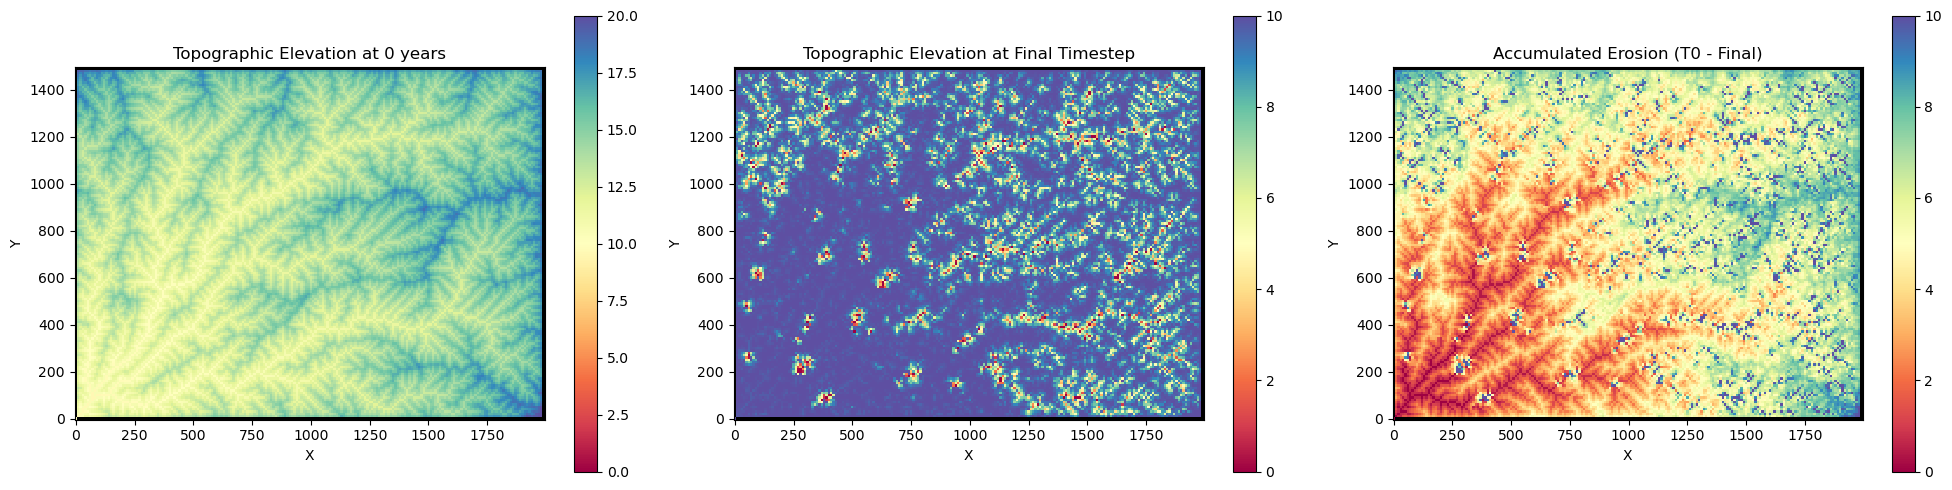

In [67]:
topoelvtn_diff = Grid_topo[0] - Grid_topo[-1]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.sca(axes[0])
imshow_grid(mg, Grid_topo[0], cmap="Spectral", vmin=0, vmax=20)
axes[0].set_title("Topographic Elevation at 0 years")
plt.sca(axes[1])
imshow_grid(mg, Grid_topo[-1], cmap="Spectral", vmin=0, vmax=10)
axes[1].set_title("Topographic Elevation at Final Timestep")
plt.sca(axes[2])
imshow_grid(mg, topoelvtn_diff, cmap="Spectral", vmin=0, vmax=10)
axes[2].set_title("Accumulated Erosion (T0 - Final)")
plt.tight_layout()
plt.show()

### Results Analysis 
1. First figure shows initial topography
2. Second figure have many yellow/red channel-like spots have appeared. The landscape looks more irregular and strongly dissected.
3. Third figure shows many yellow and higher erosion spatially which shows increase in runoff also increase the erosion in the topography

## Profile visualizer

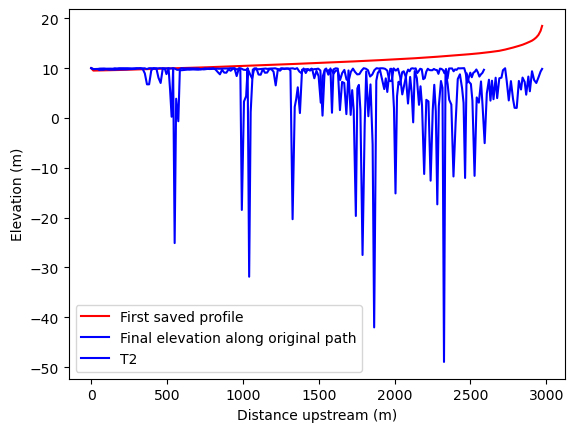

In [61]:
profile_nodes = np.asarray(lpn[0], dtype=int)
plt.plot(lpd[0], lpe[0], label="First saved profile", color="red")
plt.plot(lpd[0],Grid_topo[-1][profile_nodes],label="Final elevation along original path",color="blue",)
plt.plot(lpd[-1], lpe[-1], label="T2", color="blue")
plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

## Result
From the profile we can see that when the runoff is higher then we can see more erosion inn the upstream part and we have clamped the negtaive i.e. Deposition otherwise we can have seen the deposition in the downstream part. Still there is some instability as well representated by spikes

# 3 Visual Comparision

In [ ]:
files_a = glob.glob("Results/SpaceWithoutRunoff/SpaceWithoutRunoff_Year_*.png")
files_a.sort(key=lambda f: int(re.search(r"Year_(\d+)", os.path.basename(f)).group(1)))

files_b = glob.glob("Results/SpaceWithRunoff/SpaceWithRunoff_Year_*.png")
files_b.sort(key=lambda f: int(re.search(r"Year_(\d+)", os.path.basename(f)).group(1)))

frames = []
for fa, fb in zip(files_a, files_b):
    img_a = Image.open(fa)
    img_b = Image.open(fb)

    h = max(img_a.height, img_b.height)
    combined = Image.new("RGB", (img_a.width + img_b.width, h), "white")
    combined.paste(img_a, (0, 0))
    combined.paste(img_b, (img_a.width, 0))

    draw = ImageDraw.Draw(combined)
    year = re.search(r"Year_(\d+)", os.path.basename(fa)).group(1)
    draw.text((10, 10), f"Left: Without Runoff | Right: With Runoff | Year {year}", fill="black")

    frames.append(combined)

gif_path = "Results/comparison.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=400, loop=0)


display(IPImage(filename=gif_path))

![Bed evolution](Results/comparison.gif)

# Results

This experiment compares landscape evolution under constant runoff and variable rainfall/runoff forcing. Higher runoff periods increase sediment transport capacity and cause stronger channel incision, while lower runoff periods reduce transport capacity.

Positive bed change represents erosion, and negative bed change represents deposition. The animation helps visualize how the channel network and elevation field evolve through time.

# Future Analysis

Future work can extend this model in several ways:

- Add a sediment pulse to test whether extreme events export sediment quickly or store it within the channel network.
  
- Run sensitivity analysis for rainfall intensity, erodibility, settling velocity, sediment porosity, and timestep.

- 
- Use spatially distributed nonuniform rainfall instead of one rainfall value over the whole grid.

  
- Include infiltration or runoff generation to make rainfall-discharge coupling more realistic.

- 
- Track channel profiles, outlet sediment flux, and total erosion/deposition through time.

- 
- Test whether deposition becomes more visible under lower transport capacity or higher sediment supply.